# UNGI spine ultrasound — subject-wise 8-fold basic U-Net

This notebook trains and evaluates a basic 2D U-Net using **all frames** while keeping the eight `q...` cases completely separated.

Experimental unit: one complete case/subject.

- Outer test: one entire subject.
- Validation: one different entire subject.
- Training: all frames from the remaining six subjects.
- Eight folds: every subject is the test subject exactly once.
- No random frame-level split is allowed.

The raw arrays have already been verified as `(frames,128,128)`, images in `[0,1]`, and binary masks. This notebook repeats those checks and applies only the previously approved conversion to float32 plus a singleton channel dimension. It performs no crop, resize, padding, or flip before training. Paired horizontal flips and image-only intensity augmentation are applied during training.

**Check before training:** the first code cell must print `CORRECTED UNGI U-NET: FLOAT32, FOLD 3 FIRST, ALL 8 FOLDS`. If it prints `mixed_float16`, this is an old version and must not be run.


## 1. Runtime configuration

Kaggle recommendation: enable **GPU T4 ×2**. The code also works with one GPU or CPU. This corrected run uses float32 on every device because the earlier mixed-float16 run produced NaN validation loss on fold 3. It runs the previously failing fold 3 first, then all other folds, and reuses completed matching folds after an interruption. Validation drops only incomplete final batches to avoid a singleton-batch numerical issue. Earlier mixed-precision folds must be rerun for a consistent comparison.


In [1]:
from pathlib import Path
import gc
import hashlib
import json
import math
import os
import random
import re
import shutil
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import ndimage

import tensorflow as tf

SEED = 42
KAGGLE_INPUT = Path("/kaggle/input")
WORK_ROOT = Path("/kaggle/working/ungi_unet_8fold_fp32")
WORK_ROOT.mkdir(parents=True, exist_ok=True)

EXPECTED_CASES = [f"q{i:03d}" for i in range(8)]
EXPECTED_HW = (128, 128)
# Run the previously failing fold first, then the other seven.
FOLDS_TO_RUN = [3] + [i for i in range(8) if i != 3]

EPOCHS = 60
GLOBAL_BATCH_SIZE = 32
INITIAL_LR = 1e-3
EARLY_STOPPING_PATIENCE = 12
LR_PATIENCE = 5
BASE_FILTERS = 32
PREDICTION_THRESHOLD = 0.5

# Conservative training-only augmentation. Every original frame is still used once per epoch.
HORIZONTAL_FLIP_PROBABILITY = 0.5
INTENSITY_GAIN_RANGE = (0.90, 1.10)
INTENSITY_SHIFT_RANGE = (-0.03, 0.03)
NOISE_STD = 0.01

def seed_everything(seed=SEED):
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    tf.keras.utils.set_random_seed(seed)

seed_everything()
plt.rcParams["figure.dpi"] = 115
pd.set_option("display.max_columns", 100)

gpus = tf.config.list_physical_devices("GPU")
for gpu in gpus:
    try:
        tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError:
        pass

tf.keras.mixed_precision.set_global_policy("float32")
strategy = tf.distribute.MirroredStrategy() if len(gpus) > 1 else tf.distribute.get_strategy()

print("CORRECTED UNGI U-NET: FLOAT32, FOLD 3 FIRST, ALL 8 FOLDS")
assert tf.keras.mixed_precision.global_policy().name == "float32"
print("TensorFlow:", tf.__version__)
print("GPUs:", gpus)
print("Replicas:", strategy.num_replicas_in_sync)
print("Precision policy:", tf.keras.mixed_precision.global_policy())
print("Output root:", WORK_ROOT)


INFO:tensorflow:Using MirroredStrategy with devices ('/job:localhost/replica:0/task:0/device:GPU:0', '/job:localhost/replica:0/task:0/device:GPU:1')
CORRECTED UNGI U-NET: FLOAT32, FOLD 3 FIRST, ALL 8 FOLDS
TensorFlow: 2.20.0
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]
Replicas: 2
Precision policy: <DTypePolicy "float32">
Output root: /kaggle/working/ungi_unet_8fold_fp32


I0000 00:00:1790009850.430962      23 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1790009850.434056      23 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


## 2. Locate the eight structured cases

The search requires a directory named `sagittal_spine_data_structured` containing `q000`–`q007`, each with exactly one `Image/*.npy` and one `Mask/*.npy` volume. Ambiguous copies are rejected.


In [2]:
CASE_PATTERN = re.compile(r"^q\d+$", re.IGNORECASE)

def natural_key(value):
    return tuple(int(part) if part.isdigit() else part.lower()
                 for part in re.split(r"(\d+)", str(value)))

def candidate_roots(search_root):
    roots = []
    for path in search_root.rglob("sagittal_spine_data_structured"):
        if not path.is_dir():
            continue
        cases = sorted(
            [p.name for p in path.iterdir() if p.is_dir() and CASE_PATTERN.fullmatch(p.name)],
            key=natural_key,
        )
        if cases == EXPECTED_CASES:
            roots.append(path)
    return sorted(set(roots), key=lambda p: natural_key(str(p)))

roots = candidate_roots(KAGGLE_INPUT)
if len(roots) != 1:
    raise RuntimeError(
        f"Expected one structured UNGI root, found {len(roots)}:\n" + "\n".join(map(str, roots))
    )
DATASET_ROOT = roots[0]
print("Dataset root:", DATASET_ROOT)


Dataset root: /kaggle/input/datasets/amitismirabedini/ungi-dataset/2-Ungi Dataset/sagittal_spine_data_structured


In [3]:
def unique_volume(case, folder_name):
    folder_matches = [p for p in case.iterdir() if p.is_dir() and p.name.lower() == folder_name.lower()]
    if len(folder_matches) != 1:
        raise RuntimeError(f"{case.name}: expected one {folder_name} folder, found {folder_matches}")
    files = sorted(folder_matches[0].rglob("*.npy"), key=lambda p: natural_key(str(p)))
    if len(files) != 1:
        raise RuntimeError(f"{case.name}/{folder_name}: expected one .npy volume, found {files}")
    return files[0]

PATHS = {}
for case_name in EXPECTED_CASES:
    case_dir = DATASET_ROOT / case_name
    PATHS[case_name] = {
        "image": unique_volume(case_dir, "Image"),
        "mask": unique_volume(case_dir, "Mask"),
    }

display(pd.DataFrame([
    {"case": case, "image": str(paths["image"]), "mask": str(paths["mask"])}
    for case, paths in PATHS.items()
]))


,case,image,mask
0,q000,/kaggle/input/datasets/amitismirabedini/ungi-d...,/kaggle/input/datasets/amitismirabedini/ungi-d...
1,q001,/kaggle/input/datasets/amitismirabedini/ungi-d...,/kaggle/input/datasets/amitismirabedini/ungi-d...
2,q002,/kaggle/input/datasets/amitismirabedini/ungi-d...,/kaggle/input/datasets/amitismirabedini/ungi-d...
3,q003,/kaggle/input/datasets/amitismirabedini/ungi-d...,/kaggle/input/datasets/amitismirabedini/ungi-d...
4,q004,/kaggle/input/datasets/amitismirabedini/ungi-d...,/kaggle/input/datasets/amitismirabedini/ungi-d...
5,q005,/kaggle/input/datasets/amitismirabedini/ungi-d...,/kaggle/input/datasets/amitismirabedini/ungi-d...
6,q006,/kaggle/input/datasets/amitismirabedini/ungi-d...,/kaggle/input/datasets/amitismirabedini/ungi-d...
7,q007,/kaggle/input/datasets/amitismirabedini/ungi-d...,/kaggle/input/datasets/amitismirabedini/ungi-d...


## 3. Memory-map and re-verify every case

The volumes remain memory-mapped. The complete geometry, value range, finite-value status, binary mask values, positive-frame counts, and empty-frame counts are checked before any model is created.


In [4]:
DATA = {}
inventory_rows = []

for case in EXPECTED_CASES:
    images = np.load(PATHS[case]["image"], mmap_mode="r", allow_pickle=False)
    masks = np.load(PATHS[case]["mask"], mmap_mode="r", allow_pickle=False)
    if images.ndim == 4 and images.shape[-1] == 1:
        images = images[..., 0]
    if masks.ndim == 4 and masks.shape[-1] == 1:
        masks = masks[..., 0]
    if images.ndim != 3 or masks.ndim != 3:
        raise ValueError(f"{case}: expected (frames,H,W), got {images.shape}, {masks.shape}")
    if images.shape != masks.shape:
        raise ValueError(f"{case}: image/mask mismatch {images.shape} vs {masks.shape}")
    if tuple(images.shape[1:]) != EXPECTED_HW:
        raise ValueError(f"{case}: expected frame shape {EXPECTED_HW}, got {images.shape[1:]}")
    if not np.isfinite(images).all() or not np.isfinite(masks).all():
        raise ValueError(f"{case}: NaN or infinity detected")
    image_min, image_max = float(images.min()), float(images.max())
    mask_values = np.unique(masks)
    if image_min < 0 or image_max > 1:
        raise ValueError(f"{case}: image range [{image_min},{image_max}] is outside [0,1]")
    if not set(mask_values.tolist()).issubset({0, 1}):
        raise ValueError(f"{case}: non-binary mask values {mask_values}")

    counts = np.asarray(masks).reshape(len(masks), -1).sum(axis=1)
    DATA[case] = {
        "images": images,
        "masks": masks,
        "positive_indices": np.flatnonzero(counts > 0),
        "empty_indices": np.flatnonzero(counts == 0),
    }
    inventory_rows.append({
        "case": case,
        "frames": len(images),
        "shape": images.shape,
        "image_dtype": str(images.dtype),
        "mask_dtype": str(masks.dtype),
        "image_min": image_min,
        "image_max": image_max,
        "positive_frames": int((counts > 0).sum()),
        "empty_frames": int((counts == 0).sum()),
        "foreground_pixels": int(counts.sum()),
    })

inventory = pd.DataFrame(inventory_rows).set_index("case")
inventory["empty_percent"] = 100 * inventory.empty_frames / inventory.frames
display(inventory)
print("Total frames:", int(inventory.frames.sum()))
print("Total foreground fraction:",
      float(inventory.foreground_pixels.sum() / (inventory.frames.sum() * np.prod(EXPECTED_HW))))


,frames,shape,image_dtype,mask_dtype,image_min,image_max,positive_frames,empty_frames,foreground_pixels,empty_percent
case,,,,,,,,,,
q000,523,"(523, 128, 128)",float16,uint8,0.0,1.0,476,47,23983,8.986616
q001,355,"(355, 128, 128)",float16,uint8,0.0,1.0,265,90,14561,25.352113
q002,477,"(477, 128, 128)",float16,uint8,0.0,1.0,378,99,22485,20.754717
q003,453,"(453, 128, 128)",float16,uint8,0.0,1.0,398,55,29795,12.141280
q004,289,"(289, 128, 128)",float16,uint8,0.0,1.0,247,42,12342,14.532872
q005,387,"(387, 128, 128)",float16,uint8,0.0,1.0,352,35,22694,9.043928
q006,360,"(360, 128, 128)",float16,uint8,0.0,1.0,332,28,24965,7.777778
q007,446,"(446, 128, 128)",float16,uint8,0.0,1.0,417,29,30154,6.502242


Total frames: 3290
Total foreground fraction: 0.003357471593607523


## 4. Define and audit the eight subject-wise folds

Validation rotates to the next subject. This produces six training subjects, one validation subject, and one test subject per fold. Every subject appears exactly once as test and once as validation.


In [5]:
FOLDS = []
for fold, test_case in enumerate(EXPECTED_CASES):
    validation_case = EXPECTED_CASES[(fold + 1) % len(EXPECTED_CASES)]
    train_cases = [c for c in EXPECTED_CASES if c not in {test_case, validation_case}]
    FOLDS.append({
        "fold": fold,
        "train_cases": train_cases,
        "validation_case": validation_case,
        "test_case": test_case,
        "train_frames": int(inventory.loc[train_cases, "frames"].sum()),
        "validation_frames": int(inventory.loc[validation_case, "frames"]),
        "test_frames": int(inventory.loc[test_case, "frames"]),
    })

fold_df = pd.DataFrame(FOLDS)
display(fold_df)

for fold in FOLDS:
    train_set = set(fold["train_cases"])
    val_set = {fold["validation_case"]}
    test_set = {fold["test_case"]}
    assert len(train_set) == 6
    assert not (train_set & val_set or train_set & test_set or val_set & test_set)
assert sorted(fold_df.test_case) == EXPECTED_CASES
assert sorted(fold_df.validation_case) == EXPECTED_CASES

(WORK_ROOT / "group_folds.json").write_text(json.dumps(FOLDS, indent=2), encoding="utf-8")
print("Fold audit passed: no subject overlap.")


,fold,train_cases,validation_case,test_case,train_frames,validation_frames,test_frames
0,0,"[q002, q003, q004, q005, q006, q007]",q001,q000,2412,355,523
1,1,"[q000, q003, q004, q005, q006, q007]",q002,q001,2458,477,355
2,2,"[q000, q001, q004, q005, q006, q007]",q003,q002,2360,453,477
3,3,"[q000, q001, q002, q005, q006, q007]",q004,q003,2548,289,453
4,4,"[q000, q001, q002, q003, q006, q007]",q005,q004,2614,387,289
5,5,"[q000, q001, q002, q003, q004, q007]",q006,q005,2543,360,387
6,6,"[q000, q001, q002, q003, q004, q005]",q007,q006,2484,446,360
7,7,"[q001, q002, q003, q004, q005, q006]",q000,q007,2321,523,446


Fold audit passed: no subject overlap.


## 5. Load complete fold arrays

All frames from every selected subject are concatenated. No positive-frame oversampling and no empty-frame deletion occurs. The only shuffle is the order in which training frames are presented each epoch.


In [6]:
def stack_cases(cases):
    images = np.concatenate(
        [np.asarray(DATA[c]["images"], dtype=np.float32) for c in cases], axis=0
    )[..., None]
    masks = np.concatenate(
        [np.asarray(DATA[c]["masks"] > 0, dtype=np.float32) for c in cases], axis=0
    )[..., None]
    case_labels = np.concatenate([
        np.repeat(c, len(DATA[c]["images"])) for c in cases
    ])
    frame_indices = np.concatenate([
        np.arange(len(DATA[c]["images"]), dtype=np.int32) for c in cases
    ])
    return images, masks, case_labels, frame_indices

def augment_pair(image, mask):
    should_flip = tf.random.uniform(()) < HORIZONTAL_FLIP_PROBABILITY
    image, mask = tf.cond(
        should_flip,
        lambda: (tf.image.flip_left_right(image), tf.image.flip_left_right(mask)),
        lambda: (image, mask),
    )
    gain = tf.random.uniform((), *INTENSITY_GAIN_RANGE)
    shift = tf.random.uniform((), *INTENSITY_SHIFT_RANGE)
    image = tf.clip_by_value(image * gain + shift, 0.0, 1.0)
    image = tf.clip_by_value(image + tf.random.normal(tf.shape(image), stddev=NOISE_STD), 0.0, 1.0)
    return image, mask

def make_dataset(images, masks, training, seed=SEED, drop_remainder=False):
    ds = tf.data.Dataset.from_tensor_slices((images, masks))
    if training:
        ds = ds.shuffle(len(images), seed=seed, reshuffle_each_iteration=True)
        ds = ds.map(augment_pair, num_parallel_calls=tf.data.AUTOTUNE, deterministic=False)
    ds = ds.batch(GLOBAL_BATCH_SIZE, drop_remainder=(drop_remainder or training))
    return ds.prefetch(tf.data.AUTOTUNE)


## 6. Basic 2D U-Net and BCE + Dice objective

The architecture matches the earlier basic U-Net style: four encoder levels, a bottleneck, four decoder levels, skip connections, Batch Normalization, and a one-channel sigmoid output. All calculations use float32 to avoid the NaN validation loss observed with mixed precision.


In [7]:
def dice_coefficient_tf(y_true, y_pred, smooth=1.0):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)
    axes = tuple(range(1, len(y_true.shape)))
    intersection = tf.reduce_sum(y_true * y_pred, axis=axes)
    denominator = tf.reduce_sum(y_true, axis=axes) + tf.reduce_sum(y_pred, axis=axes)
    dice = (2.0 * intersection + smooth) / (denominator + smooth)
    return tf.reduce_mean(dice)

def bce_dice_loss(y_true, y_pred):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)
    bce = tf.reduce_mean(tf.keras.losses.binary_crossentropy(y_true, y_pred))
    return bce + (1.0 - dice_coefficient_tf(y_true, y_pred))

def conv_block(x, filters):
    for _ in range(2):
        x = tf.keras.layers.Conv2D(filters, 3, padding="same", use_bias=False)(x)
        x = tf.keras.layers.BatchNormalization()(x)
        x = tf.keras.layers.Activation("relu")(x)
    return x

def build_unet(base_filters=BASE_FILTERS):
    inputs = tf.keras.Input((*EXPECTED_HW, 1), name="ultrasound")
    skips = []
    x = inputs
    for filters in [base_filters, base_filters*2, base_filters*4, base_filters*8]:
        x = conv_block(x, filters)
        skips.append(x)
        x = tf.keras.layers.MaxPool2D(2)(x)
    x = conv_block(x, base_filters*16)
    for filters, skip in zip(
        [base_filters*8, base_filters*4, base_filters*2, base_filters], reversed(skips)
    ):
        x = tf.keras.layers.Conv2DTranspose(filters, 2, strides=2, padding="same")(x)
        x = tf.keras.layers.Concatenate()([x, skip])
        x = conv_block(x, filters)
    outputs = tf.keras.layers.Conv2D(1, 1, activation="sigmoid", dtype="float32", name="mask")(x)
    return tf.keras.Model(inputs, outputs, name="UNGI_basic_UNet")

with strategy.scope():
    audit_model = build_unet()
    audit_model.compile(
        optimizer=tf.keras.optimizers.Adam(INITIAL_LR),
        loss=bce_dice_loss,
        metrics=[dice_coefficient_tf],
    )
print("Model parameters:", f"{audit_model.count_params():,}")
print("Input:", audit_model.input_shape, "Output:", audit_model.output_shape)
del audit_model
tf.keras.backend.clear_session()


Model parameters: 7,768,353
Input: (None, 128, 128, 1) Output: (None, 128, 128, 1)


## 7. Evaluation functions

The primary score is subject-level foreground Dice computed from all pixels of the held-out subject. Frame-level results distinguish positive frames from empty frames. HD95 and ASSD are evaluated on positive ground-truth frames; a missing prediction receives an image-diagonal penalty.


In [8]:
def confusion_counts(truth, pred):
    truth = np.asarray(truth, dtype=bool)
    pred = np.asarray(pred, dtype=bool)
    tp = int(np.logical_and(truth, pred).sum())
    fp = int(np.logical_and(~truth, pred).sum())
    fn = int(np.logical_and(truth, ~pred).sum())
    tn = int(np.logical_and(~truth, ~pred).sum())
    return tp, fp, fn, tn

def overlap_metrics(tp, fp, fn):
    dice = 2 * tp / max(2 * tp + fp + fn, 1)
    iou = tp / max(tp + fp + fn, 1)
    precision = tp / max(tp + fp, 1)
    recall = tp / max(tp + fn, 1)
    return dice, iou, precision, recall

def surface_distances(truth, pred):
    truth = np.asarray(truth, dtype=bool)
    pred = np.asarray(pred, dtype=bool)
    diagonal = float(np.hypot(*truth.shape))
    if not truth.any():
        return np.nan, np.nan
    if not pred.any():
        return diagonal, diagonal
    truth_surface = truth ^ ndimage.binary_erosion(truth)
    pred_surface = pred ^ ndimage.binary_erosion(pred)
    dist_to_pred = ndimage.distance_transform_edt(~pred_surface)
    dist_to_truth = ndimage.distance_transform_edt(~truth_surface)
    distances = np.concatenate([dist_to_pred[truth_surface], dist_to_truth[pred_surface]])
    return float(np.percentile(distances, 95)), float(np.mean(distances))

def evaluate_subject(case, probabilities, threshold=PREDICTION_THRESHOLD):
    truth = np.asarray(DATA[case]["masks"] > 0, dtype=np.uint8)
    pred = (np.asarray(probabilities) >= threshold).astype(np.uint8)
    if pred.shape != truth.shape:
        raise ValueError(f"{case}: prediction {pred.shape}, truth {truth.shape}")

    rows = []
    for frame_index in range(len(truth)):
        gt = truth[frame_index]
        pd_mask = pred[frame_index]
        tp, fp, fn, tn = confusion_counts(gt, pd_mask)
        dice, iou, precision, recall = overlap_metrics(tp, fp, fn)
        gt_positive = bool(gt.any())
        pred_positive = bool(pd_mask.any())
        hd95, assd = surface_distances(gt, pd_mask)
        rows.append({
            "case": case,
            "frame_index": frame_index,
            "gt_positive": gt_positive,
            "pred_positive": pred_positive,
            "tp": tp, "fp": fp, "fn": fn, "tn": tn,
            "dice": dice, "iou": iou, "precision": precision, "recall": recall,
            "hd95_pixels": hd95, "assd_pixels": assd,
        })
    frames = pd.DataFrame(rows)
    tp, fp, fn, tn = confusion_counts(truth, pred)
    dice, iou, precision, recall = overlap_metrics(tp, fp, fn)
    positive = frames[frames.gt_positive]
    empty = frames[~frames.gt_positive]
    summary = {
        "subject": case,
        "frames": len(frames),
        "positive_frames": len(positive),
        "empty_frames": len(empty),
        "subject_micro_dice": dice,
        "subject_micro_iou": iou,
        "subject_micro_precision": precision,
        "subject_micro_recall": recall,
        "mean_positive_frame_dice": float(positive.dice.mean()),
        "median_positive_frame_dice": float(positive.dice.median()),
        "mean_hd95_pixels": float(positive.hd95_pixels.mean()),
        "mean_assd_pixels": float(positive.assd_pixels.mean()),
        "missed_positive_frames": int((~positive.pred_positive).sum()),
        "false_positive_empty_frames": int(empty.pred_positive.sum()),
        "empty_frame_specificity": float((~empty.pred_positive).mean()) if len(empty) else np.nan,
        "threshold": threshold,
    }
    return frames, summary, pred


## 8. Train all eight folds

Each epoch contains every training frame exactly once. Augmentation changes only the training presentation; original frames are not removed. Validation and testing are never augmented. Early stopping restores the weights with the best finite validation loss. Non-finite validation metrics now fail immediately. Completed folds can be reused safely on a rerun with the same inputs and settings. This float32 run uses a separate output directory.


Corrected run signature: 22a08619f2eda685e1d9

Fold 3: train=['q000', 'q001', 'q002', 'q005', 'q006', 'q007'], val=q004, test=q003
Arrays: (2548, 128, 128, 1) (289, 128, 128, 1) (453, 128, 128, 1)
All training cases represented: [np.str_('q000'), np.str_('q001'), np.str_('q002'), np.str_('q005'), np.str_('q006'), np.str_('q007')]
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/re

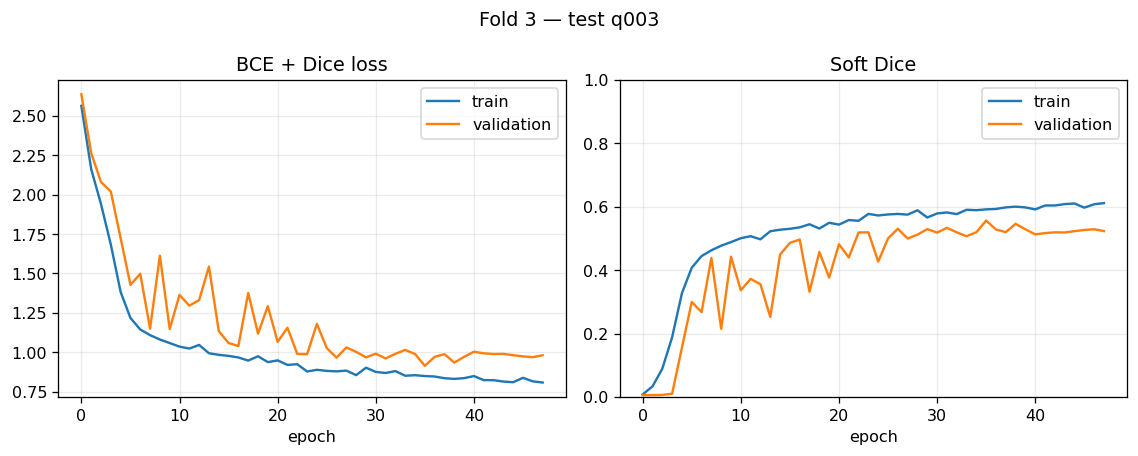

15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 168ms/step


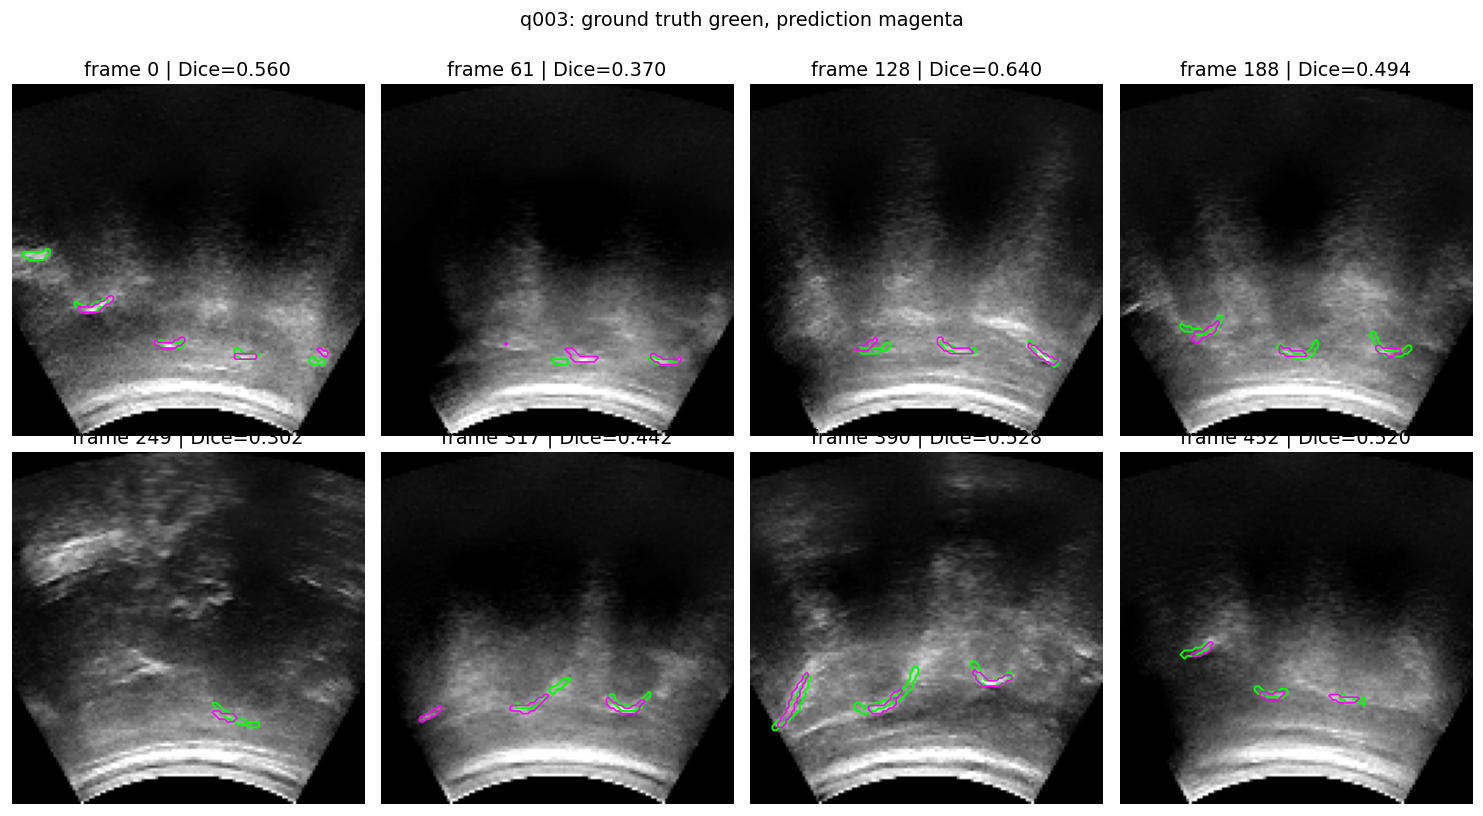


Fold 0: train=['q002', 'q003', 'q004', 'q005', 'q006', 'q007'], val=q001, test=q000
Arrays: (2412, 128, 128, 1) (355, 128, 128, 1) (523, 128, 128, 1)
All training cases represented: [np.str_('q002'), np.str_('q003'), np.str_('q004'), np.str_('q005'), np.str_('q006'), np.str_('q007')]
Epoch 1/60
INFO:tensorflow:Collective all_reduce tensors: 64 all_reduces, num_devices = 2, group_size = 2, implementation = CommunicationImplementation.NCCL, num_packs = 1

Epoch 1: val_loss improved from None to 3.36024, saving model to /kaggle/working/ungi_unet_8fold_fp32/fold_0_q000/best.weights.h5

Epoch 1: finished saving model to /kaggle/working/ungi_unet_8fold_fp32/fold_0_q000/best.weights.h5
75/75 - 22s - 289ms/step - dice_coefficient_tf: 0.0087 - loss: 2.5721 - val_dice_coefficient_tf: 0.0061 - val_loss: 3.3602 - learning_rate: 0.0010
Epoch 2/60

Epoch 2: val_loss improved from 3.36024 to 2.30568, saving model to /kaggle/working/ungi_unet_8fold_fp32/fold_0_q000/best.weights.h5

Epoch 2: finished 

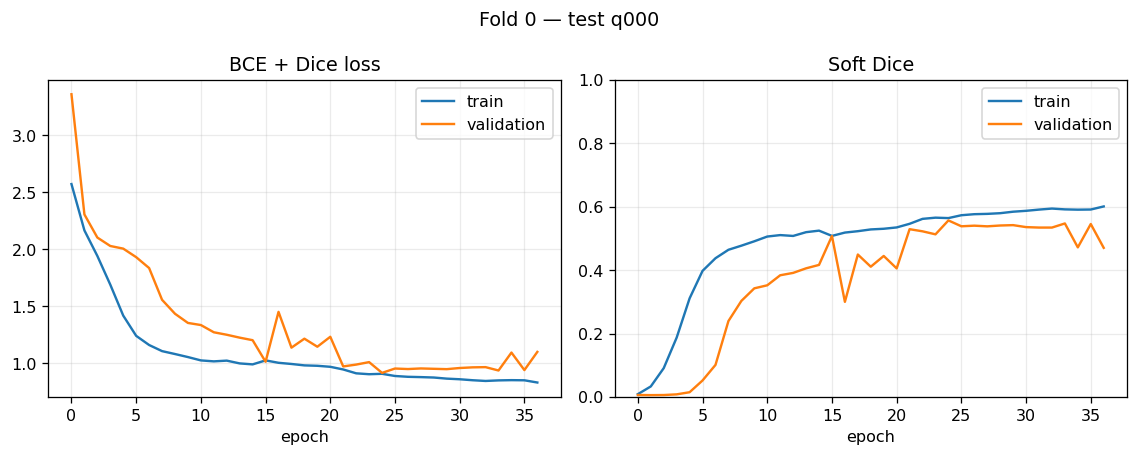

17/17 ━━━━━━━━━━━━━━━━━━━━ 3s 131ms/step


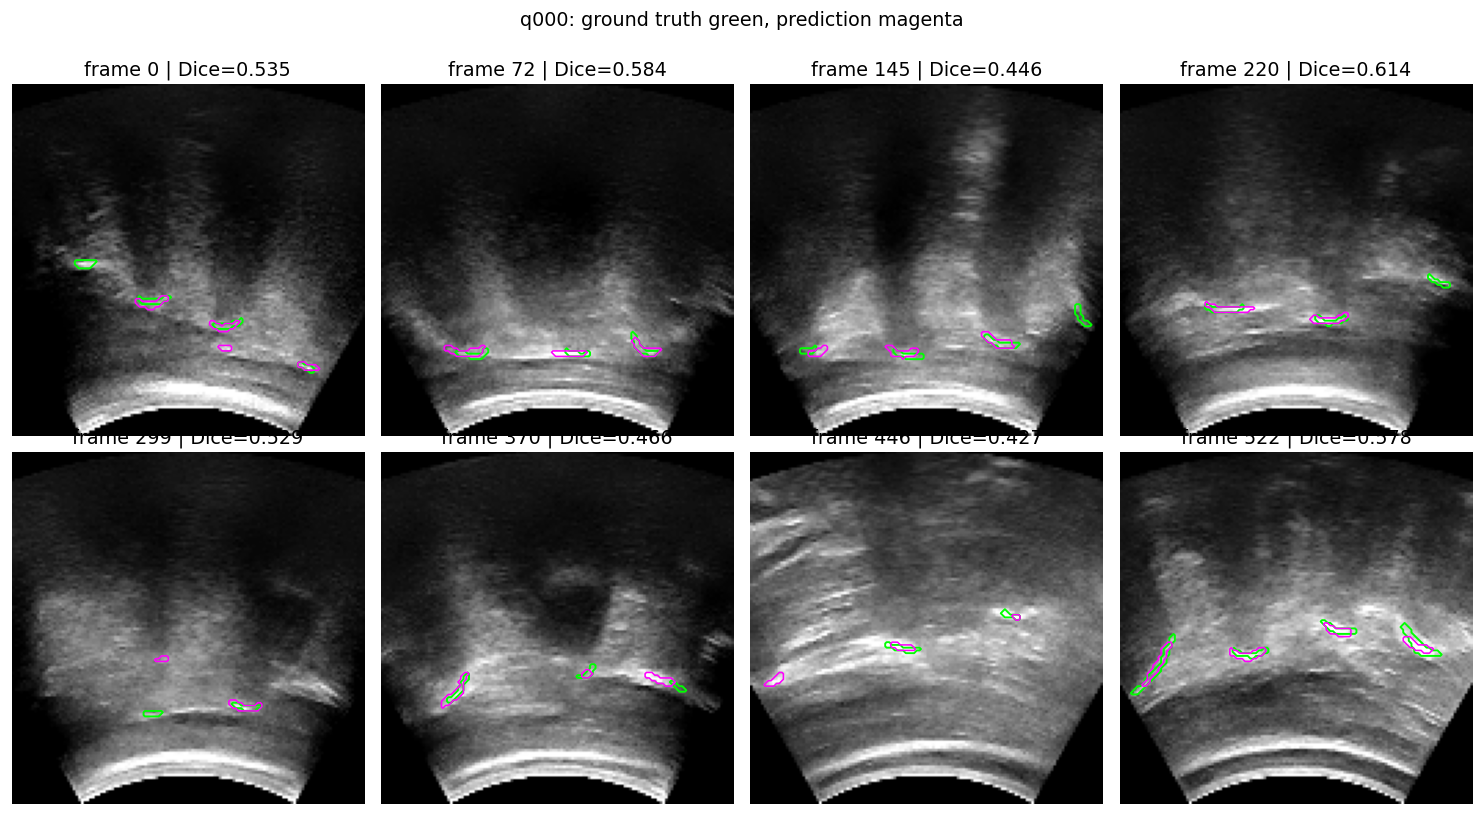


Fold 1: train=['q000', 'q003', 'q004', 'q005', 'q006', 'q007'], val=q002, test=q001
Arrays: (2458, 128, 128, 1) (477, 128, 128, 1) (355, 128, 128, 1)
All training cases represented: [np.str_('q000'), np.str_('q003'), np.str_('q004'), np.str_('q005'), np.str_('q006'), np.str_('q007')]
Epoch 1/60
INFO:tensorflow:Collective all_reduce tensors: 64 all_reduces, num_devices = 2, group_size = 2, implementation = CommunicationImplementation.NCCL, num_packs = 1

Epoch 1: val_loss improved from None to 2.51350, saving model to /kaggle/working/ungi_unet_8fold_fp32/fold_1_q001/best.weights.h5

Epoch 1: finished saving model to /kaggle/working/ungi_unet_8fold_fp32/fold_1_q001/best.weights.h5
76/76 - 23s - 300ms/step - dice_coefficient_tf: 0.0086 - loss: 2.5791 - val_dice_coefficient_tf: 0.0055 - val_loss: 2.5135 - learning_rate: 0.0010
Epoch 2/60

Epoch 2: val_loss improved from 2.51350 to 2.28396, saving model to /kaggle/working/ungi_unet_8fold_fp32/fold_1_q001/best.weights.h5

Epoch 2: finished 

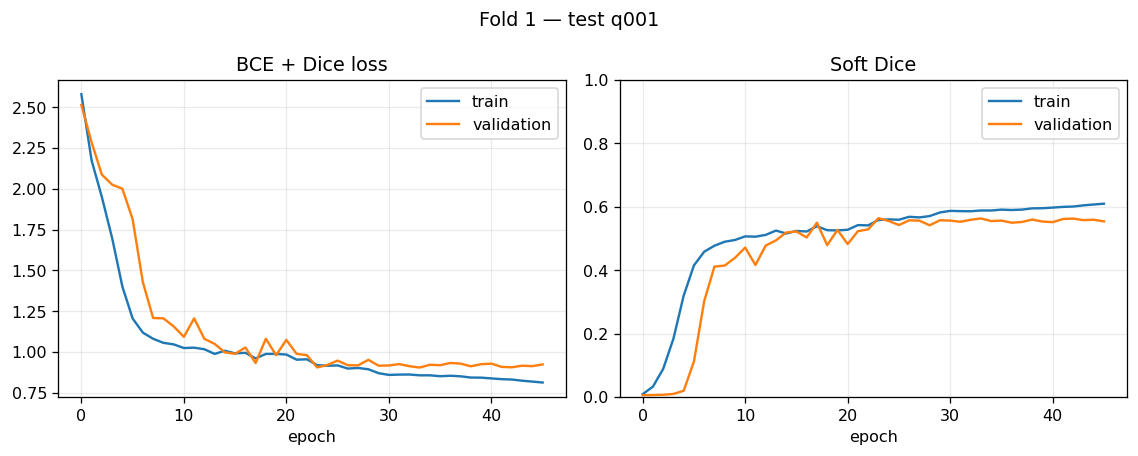

12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 166ms/step


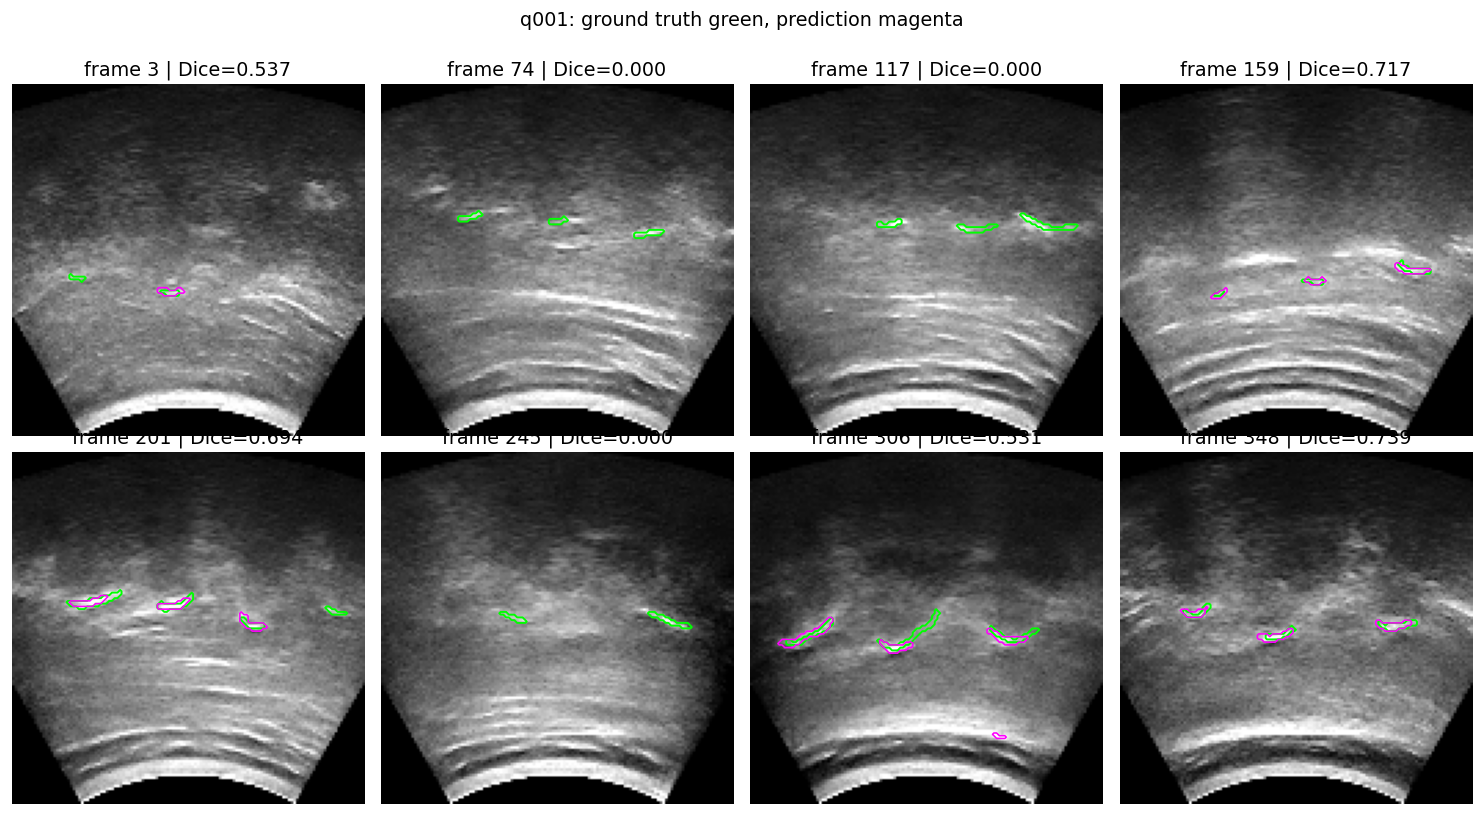


Fold 2: train=['q000', 'q001', 'q004', 'q005', 'q006', 'q007'], val=q003, test=q002
Arrays: (2360, 128, 128, 1) (453, 128, 128, 1) (477, 128, 128, 1)
All training cases represented: [np.str_('q000'), np.str_('q001'), np.str_('q004'), np.str_('q005'), np.str_('q006'), np.str_('q007')]
Epoch 1/60
INFO:tensorflow:Collective all_reduce tensors: 64 all_reduces, num_devices = 2, group_size = 2, implementation = CommunicationImplementation.NCCL, num_packs = 1

Epoch 1: val_loss improved from None to 2.65413, saving model to /kaggle/working/ungi_unet_8fold_fp32/fold_2_q002/best.weights.h5

Epoch 1: finished saving model to /kaggle/working/ungi_unet_8fold_fp32/fold_2_q002/best.weights.h5
73/73 - 22s - 303ms/step - dice_coefficient_tf: 0.0071 - loss: 2.5822 - val_dice_coefficient_tf: 0.0084 - val_loss: 2.6541 - learning_rate: 0.0010
Epoch 2/60

Epoch 2: val_loss improved from 2.65413 to 2.29999, saving model to /kaggle/working/ungi_unet_8fold_fp32/fold_2_q002/best.weights.h5

Epoch 2: finished 

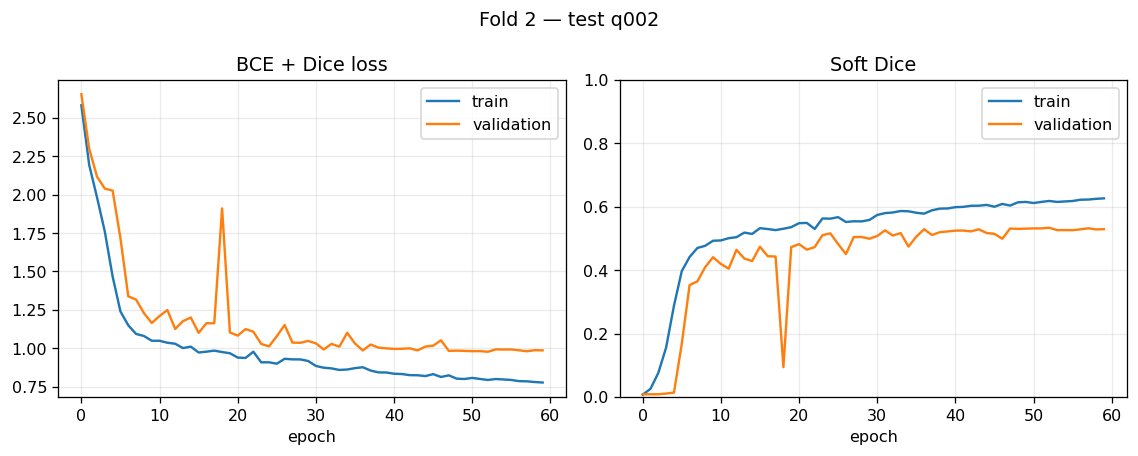

15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 170ms/step


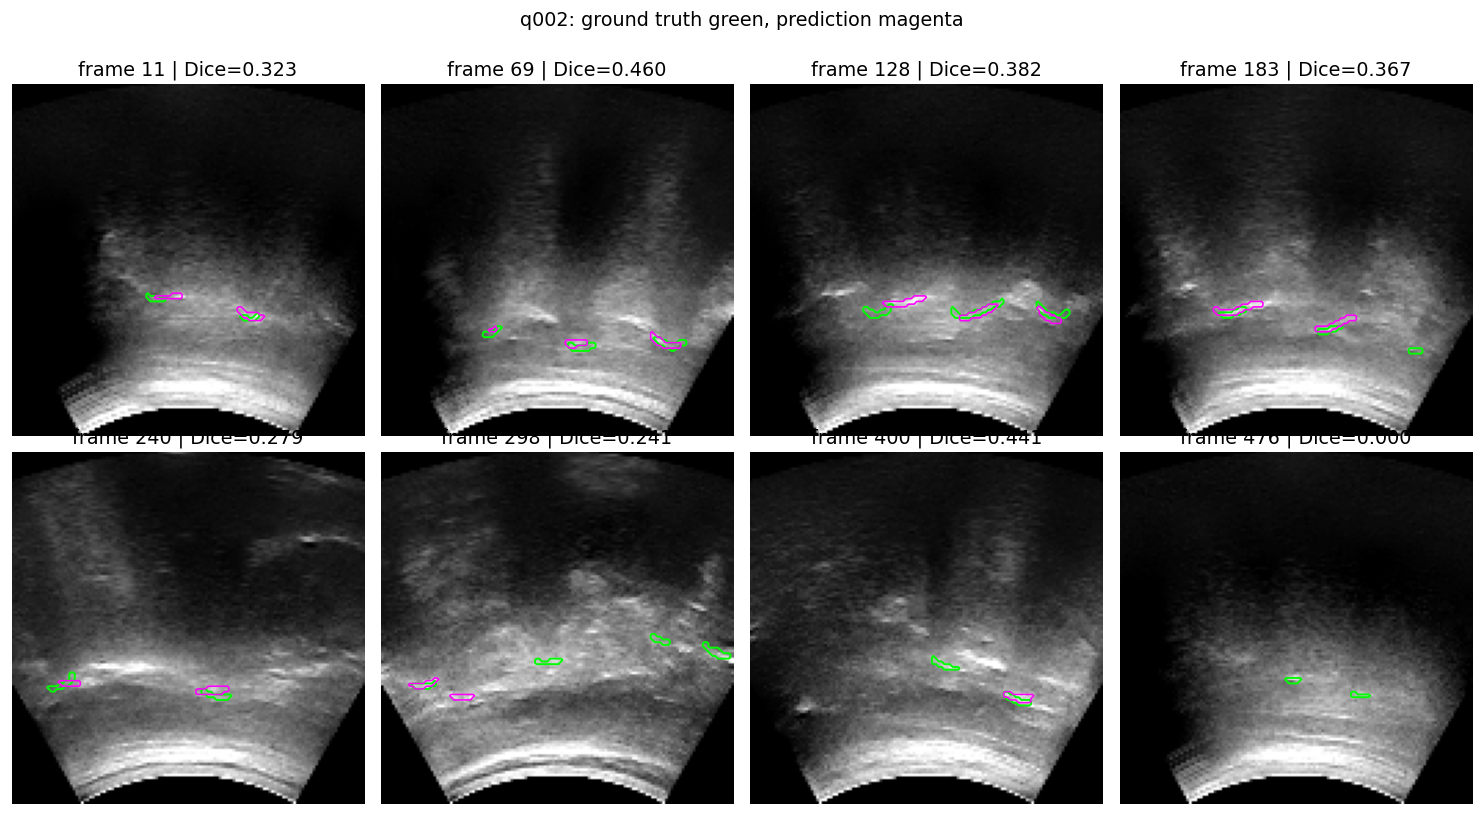


Fold 4: train=['q000', 'q001', 'q002', 'q003', 'q006', 'q007'], val=q005, test=q004
Arrays: (2614, 128, 128, 1) (387, 128, 128, 1) (289, 128, 128, 1)
All training cases represented: [np.str_('q000'), np.str_('q001'), np.str_('q002'), np.str_('q003'), np.str_('q006'), np.str_('q007')]
Epoch 1/60
INFO:tensorflow:Collective all_reduce tensors: 64 all_reduces, num_devices = 2, group_size = 2, implementation = CommunicationImplementation.NCCL, num_packs = 1

Epoch 1: val_loss improved from None to 2.31801, saving model to /kaggle/working/ungi_unet_8fold_fp32/fold_4_q004/best.weights.h5

Epoch 1: finished saving model to /kaggle/working/ungi_unet_8fold_fp32/fold_4_q004/best.weights.h5
81/81 - 23s - 289ms/step - dice_coefficient_tf: 0.0087 - loss: 2.5476 - val_dice_coefficient_tf: 0.0072 - val_loss: 2.3180 - learning_rate: 0.0010
Epoch 2/60

Epoch 2: val_loss improved from 2.31801 to 2.24063, saving model to /kaggle/working/ungi_unet_8fold_fp32/fold_4_q004/best.weights.h5

Epoch 2: finished 

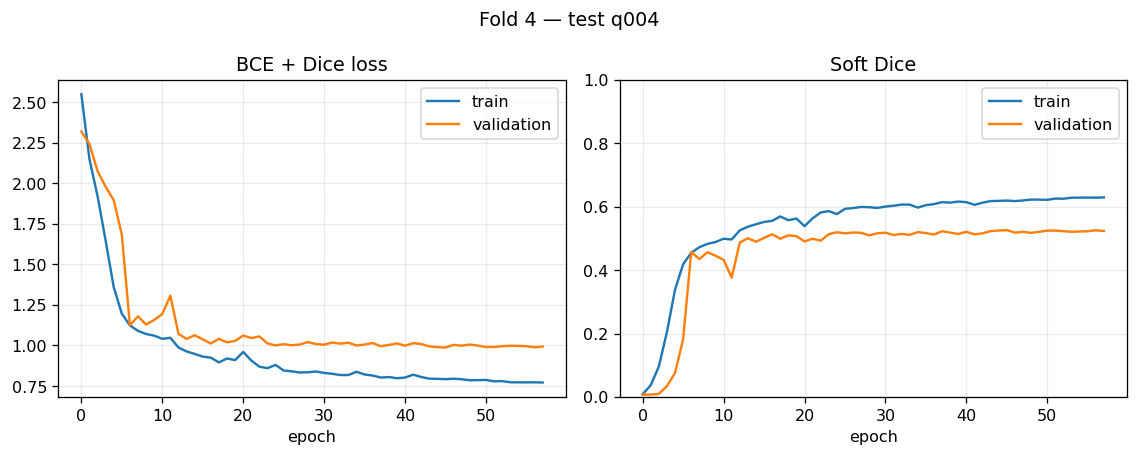

10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 183ms/step


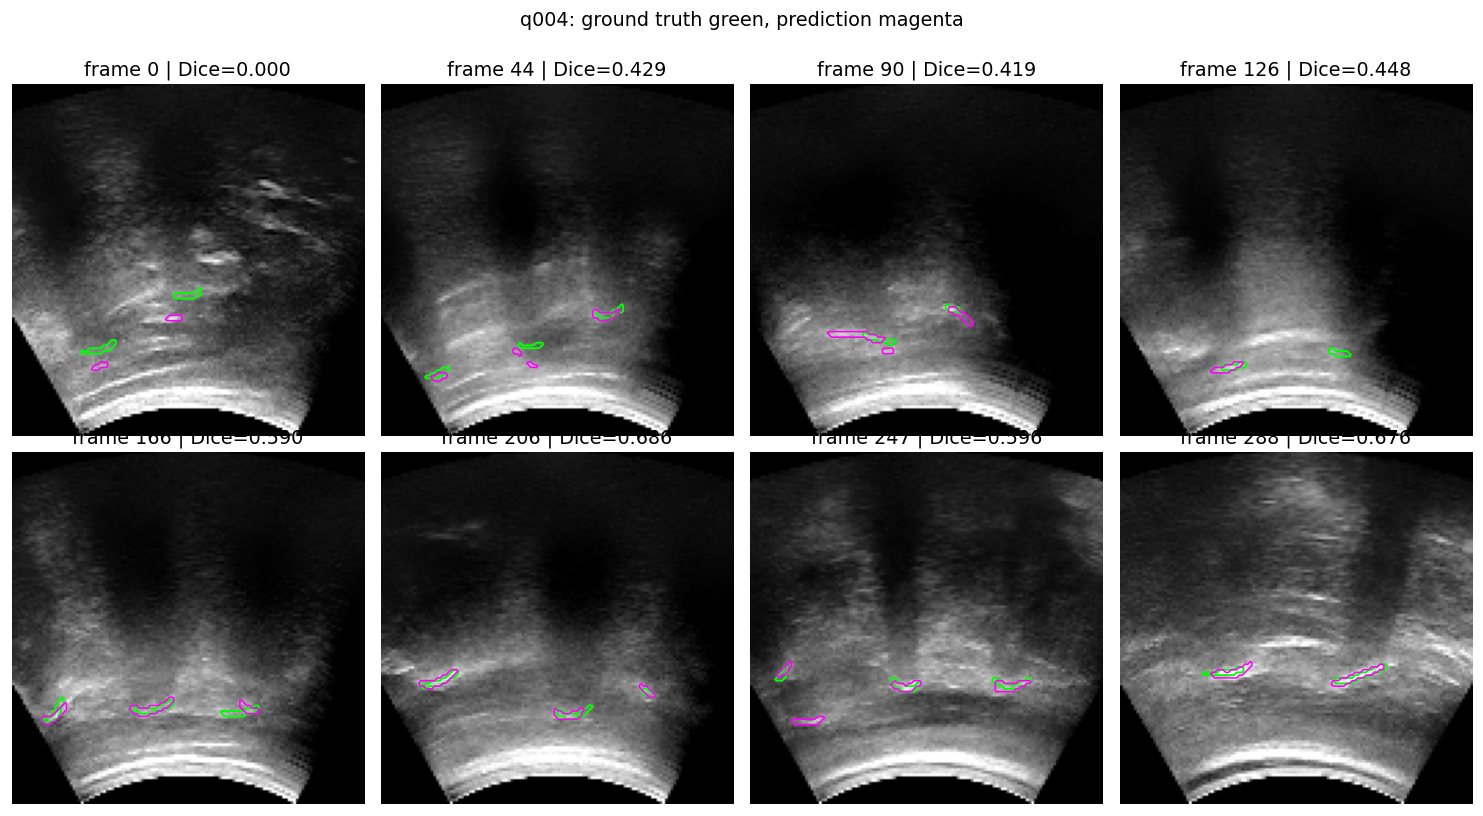


Fold 5: train=['q000', 'q001', 'q002', 'q003', 'q004', 'q007'], val=q006, test=q005
Arrays: (2543, 128, 128, 1) (360, 128, 128, 1) (387, 128, 128, 1)
All training cases represented: [np.str_('q000'), np.str_('q001'), np.str_('q002'), np.str_('q003'), np.str_('q004'), np.str_('q007')]
Epoch 1/60
INFO:tensorflow:Collective all_reduce tensors: 64 all_reduces, num_devices = 2, group_size = 2, implementation = CommunicationImplementation.NCCL, num_packs = 1

Epoch 1: val_loss improved from None to 2.44783, saving model to /kaggle/working/ungi_unet_8fold_fp32/fold_5_q005/best.weights.h5

Epoch 1: finished saving model to /kaggle/working/ungi_unet_8fold_fp32/fold_5_q005/best.weights.h5
79/79 - 23s - 288ms/step - dice_coefficient_tf: 0.0075 - loss: 2.5632 - val_dice_coefficient_tf: 0.0095 - val_loss: 2.4478 - learning_rate: 0.0010
Epoch 2/60

Epoch 2: val_loss improved from 2.44783 to 2.24702, saving model to /kaggle/working/ungi_unet_8fold_fp32/fold_5_q005/best.weights.h5

Epoch 2: finished 

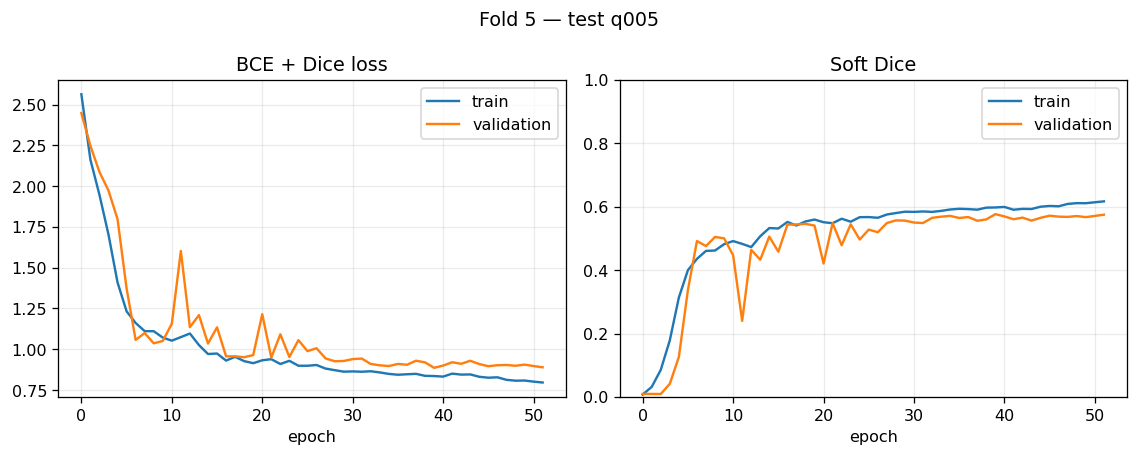

13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 182ms/step


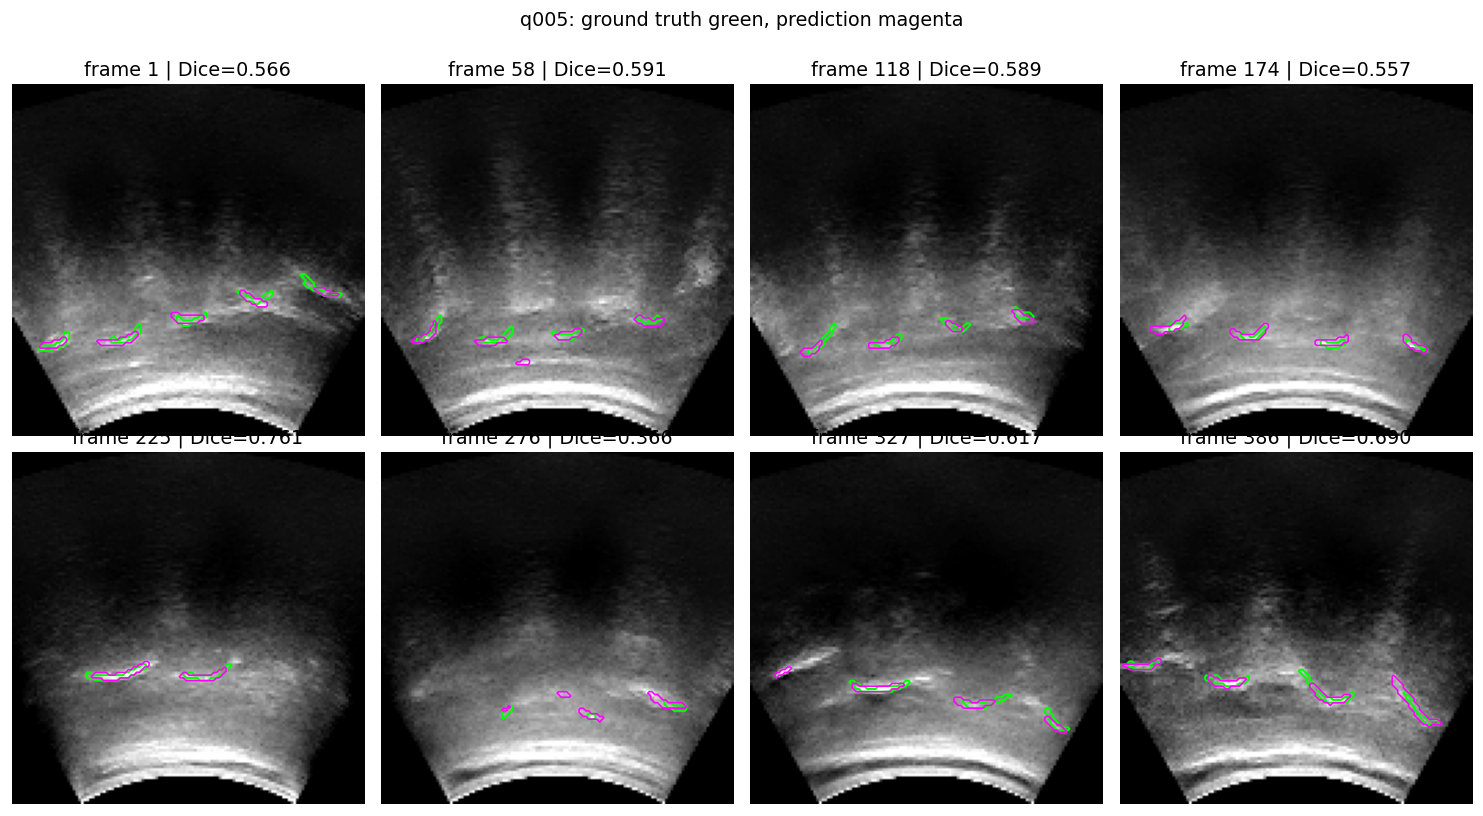


Fold 6: train=['q000', 'q001', 'q002', 'q003', 'q004', 'q005'], val=q007, test=q006
Arrays: (2484, 128, 128, 1) (446, 128, 128, 1) (360, 128, 128, 1)
All training cases represented: [np.str_('q000'), np.str_('q001'), np.str_('q002'), np.str_('q003'), np.str_('q004'), np.str_('q005')]
Epoch 1/60
INFO:tensorflow:Collective all_reduce tensors: 64 all_reduces, num_devices = 2, group_size = 2, implementation = CommunicationImplementation.NCCL, num_packs = 1

Epoch 1: val_loss improved from None to 2.72603, saving model to /kaggle/working/ungi_unet_8fold_fp32/fold_6_q006/best.weights.h5

Epoch 1: finished saving model to /kaggle/working/ungi_unet_8fold_fp32/fold_6_q006/best.weights.h5
77/77 - 23s - 295ms/step - dice_coefficient_tf: 0.0066 - loss: 2.5685 - val_dice_coefficient_tf: 0.0094 - val_loss: 2.7260 - learning_rate: 0.0010
Epoch 2/60

Epoch 2: val_loss improved from 2.72603 to 2.29208, saving model to /kaggle/working/ungi_unet_8fold_fp32/fold_6_q006/best.weights.h5

Epoch 2: finished 

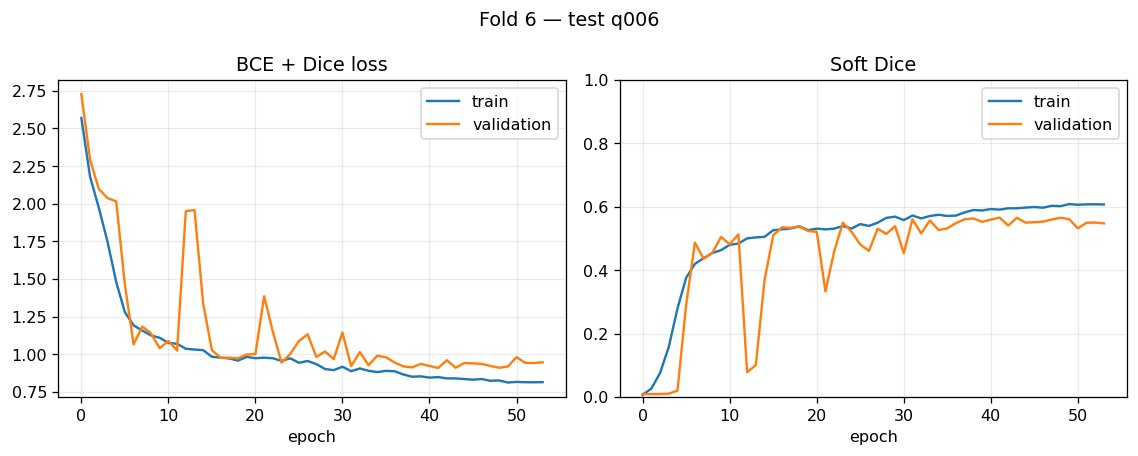

12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 166ms/step


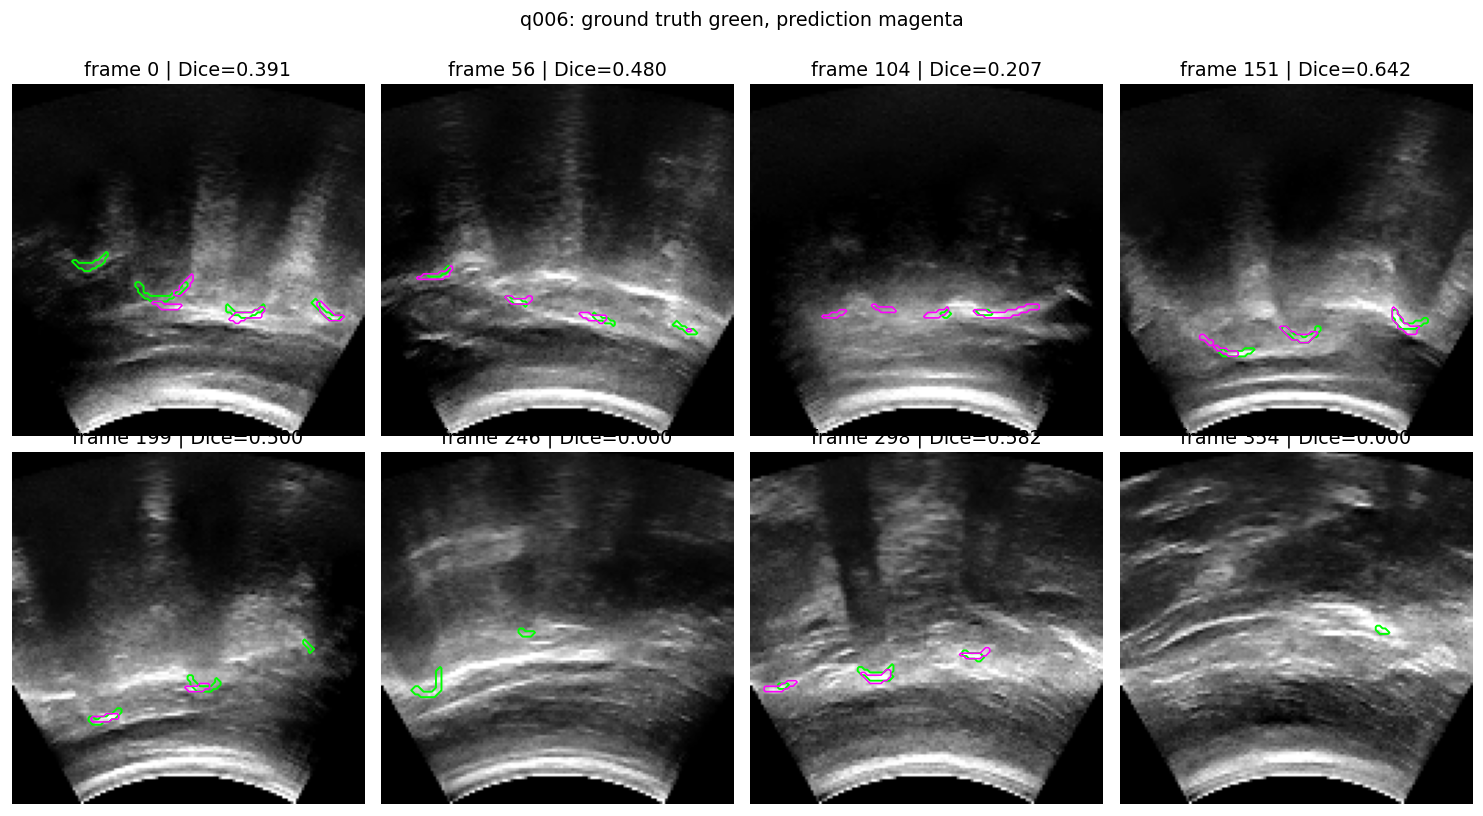


Fold 7: train=['q001', 'q002', 'q003', 'q004', 'q005', 'q006'], val=q000, test=q007
Arrays: (2321, 128, 128, 1) (523, 128, 128, 1) (446, 128, 128, 1)
All training cases represented: [np.str_('q001'), np.str_('q002'), np.str_('q003'), np.str_('q004'), np.str_('q005'), np.str_('q006')]
Epoch 1/60
INFO:tensorflow:Collective all_reduce tensors: 64 all_reduces, num_devices = 2, group_size = 2, implementation = CommunicationImplementation.NCCL, num_packs = 1

Epoch 1: val_loss improved from None to 2.73075, saving model to /kaggle/working/ungi_unet_8fold_fp32/fold_7_q007/best.weights.h5

Epoch 1: finished saving model to /kaggle/working/ungi_unet_8fold_fp32/fold_7_q007/best.weights.h5
72/72 - 22s - 311ms/step - dice_coefficient_tf: 0.0069 - loss: 2.5903 - val_dice_coefficient_tf: 0.0065 - val_loss: 2.7308 - learning_rate: 0.0010
Epoch 2/60

Epoch 2: val_loss improved from 2.73075 to 2.30606, saving model to /kaggle/working/ungi_unet_8fold_fp32/fold_7_q007/best.weights.h5

Epoch 2: finished 

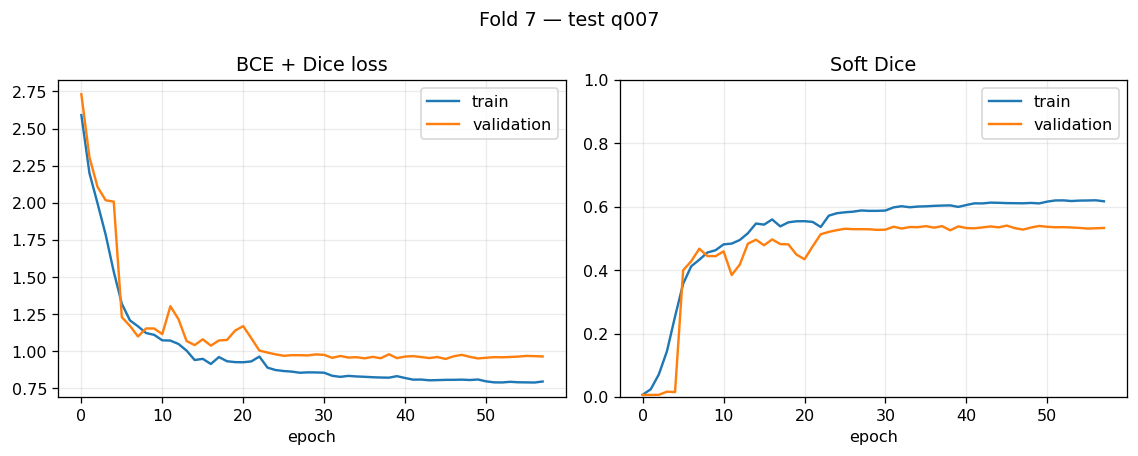

14/14 ━━━━━━━━━━━━━━━━━━━━ 3s 175ms/step


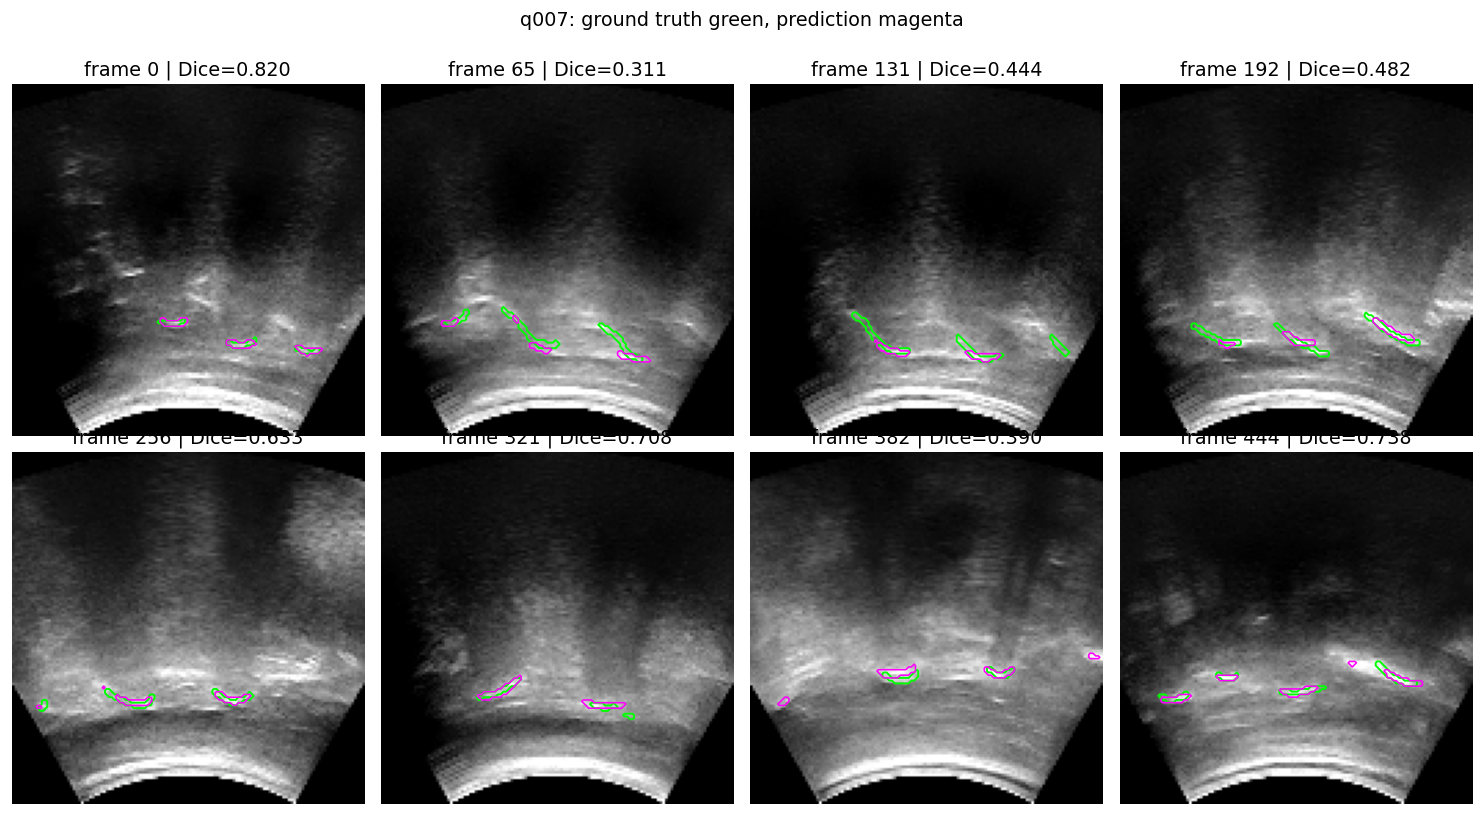

,subject,frames,positive_frames,empty_frames,subject_micro_dice,subject_micro_iou,subject_micro_precision,subject_micro_recall,mean_positive_frame_dice,median_positive_frame_dice,mean_hd95_pixels,mean_assd_pixels,missed_positive_frames,false_positive_empty_frames,empty_frame_specificity,threshold,fold,validation_subject,train_subjects,epochs_completed,best_epoch,best_val_loss,run_signature,training_seconds
1,q000,523,476,47,0.540660,0.370482,0.511650,0.573156,0.514292,0.541028,23.623363,12.184744,22,19,0.595745,0.5,0,q001,"[q002, q003, q004, q005, q006, q007]",37,25,0.915471,22a08619f2eda685e1d9,453.087616
2,q001,355,265,90,0.510853,0.343050,0.516721,0.505116,0.463608,0.531120,37.232840,24.413345,29,34,0.622222,0.5,1,q002,"[q000, q003, q004, q005, q006, q007]",46,34,0.904038,22a08619f2eda685e1d9,581.630524
3,q002,477,378,99,0.536684,0.366759,0.529766,0.543785,0.518375,0.552239,20.780139,10.102090,15,25,0.747475,0.5,2,q003,"[q000, q001, q004, q005, q006, q007]",60,53,0.976429,22a08619f2eda685e1d9,711.629286
0,q003,453,398,55,0.514226,0.346100,0.551167,0.481926,0.490065,0.519778,19.063588,8.304661,11,22,0.600000,0.5,3,q004,"[q000, q001, q002, q005, q006, q007]",48,36,0.912987,22a08619f2eda685e1d9,615.697124
4,q004,289,247,42,0.557487,0.386469,0.519337,0.601685,0.530039,0.564516,18.798163,8.125850,6,20,0.523810,0.5,4,q005,"[q000, q001, q002, q003, q006, q007]",58,46,0.986988,22a08619f2eda685e1d9,749.140358
5,q005,387,352,35,0.531780,0.362193,0.462006,0.626377,0.499259,0.541126,18.987661,10.424427,15,11,0.685714,0.5,5,q006,"[q000, q001, q002, q003, q004, q007]",52,40,0.885812,22a08619f2eda685e1d9,658.891442
6,q006,360,332,28,0.584220,0.412649,0.598287,0.570799,0.555214,0.600172,19.608603,9.985831,13,8,0.714286,0.5,6,q007,"[q000, q001, q002, q003, q004, q005]",54,42,0.909207,22a08619f2eda685e1d9,684.253352
7,q007,446,417,29,0.564137,0.392891,0.593705,0.537375,0.541124,0.569892,16.111110,8.700568,15,5,0.827586,0.5,7,q000,"[q001, q002, q003, q004, q005, q006]",58,46,0.948234,22a08619f2eda685e1d9,695.316953


In [9]:
# A signature prevents mixing different data, folds, training settings, and numerical policies.
run_configuration = {
    "protocol": "UNGI_basic_UNet_8fold_float32_v2", "tensorflow": tf.__version__,
    "seed": SEED, "epochs": EPOCHS, "batch_size": GLOBAL_BATCH_SIZE,
    "learning_rate": INITIAL_LR, "early_stopping_patience": EARLY_STOPPING_PATIENCE,
    "lr_patience": LR_PATIENCE, "base_filters": BASE_FILTERS,
    "threshold": PREDICTION_THRESHOLD, "precision": "float32",
    "augment": [HORIZONTAL_FLIP_PROBABILITY, INTENSITY_GAIN_RANGE,
                INTENSITY_SHIFT_RANGE, NOISE_STD],
    "inputs": [
        {"case": case, "image": str(PATHS[case]["image"]),
         "image_size": PATHS[case]["image"].stat().st_size,
         "mask": str(PATHS[case]["mask"]),
         "mask_size": PATHS[case]["mask"].stat().st_size,
         "frames": int(inventory.loc[case, "frames"]),
         "foreground_pixels": int(inventory.loc[case, "foreground_pixels"])}
        for case in EXPECTED_CASES
    ],
}
RUN_SIGNATURE = hashlib.sha256(
    json.dumps(run_configuration, sort_keys=True).encode("utf-8")
).hexdigest()[:20]
print("Corrected run signature:", RUN_SIGNATURE)
(WORK_ROOT / "run_configuration.json").write_text(
    json.dumps({**run_configuration, "run_signature": RUN_SIGNATURE}, indent=2),
    encoding="utf-8",
)

class RequireFiniteValidation(tf.keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        for key in ("loss", "val_loss", "val_dice_coefficient_tf"):
            value = logs.get(key)
            if value is None or not np.isfinite(float(value)):
                raise FloatingPointError(
                    f"Epoch {epoch + 1}: {key}={value!r}. "
                    "This fold has no valid validation result. Check the validation "
                    "subject and numeric policy before reporting its test score."
                )

def completed_fold(fold_index):
    fold = FOLDS[fold_index]
    case = fold["test_case"]
    directory = WORK_ROOT / f"fold_{fold_index}_{case}"
    required = [directory / "subject_summary.json", directory / "test_frame_metrics.csv",
                directory / "best.weights.h5", directory / f"{case}_probabilities.npy",
                directory / f"{case}_predictions.npy"]
    if any(not p.is_file() or p.stat().st_size == 0 for p in required):
        return None
    try:
        summary = json.loads(required[0].read_text(encoding="utf-8"))
        if (summary.get("run_signature") != RUN_SIGNATURE or
            summary.get("subject") != case or summary.get("fold") != fold_index or
            summary.get("validation_subject") != fold["validation_case"] or
            summary.get("train_subjects") != fold["train_cases"] or
            summary.get("frames") != fold["test_frames"] or
            not np.isfinite(float(summary["subject_micro_dice"]))):
            return None
        frames = pd.read_csv(required[1])
        return (summary, frames) if len(frames) == fold["test_frames"] else None
    except (OSError, ValueError, KeyError, TypeError):
        return None

def plot_history(history_df, fold_dir, fold, test_case):
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    axes[0].plot(history_df.loss, label="train")
    axes[0].plot(history_df.val_loss, label="validation")
    axes[0].set_title("BCE + Dice loss")
    axes[0].set_xlabel("epoch")
    axes[0].legend()
    axes[0].grid(alpha=0.25)
    axes[1].plot(history_df.dice_coefficient_tf, label="train")
    axes[1].plot(history_df.val_dice_coefficient_tf, label="validation")
    axes[1].set_title("Soft Dice")
    axes[1].set_xlabel("epoch")
    axes[1].set_ylim(0, 1)
    axes[1].legend()
    axes[1].grid(alpha=0.25)
    fig.suptitle(f"Fold {fold} — test {test_case}")
    plt.tight_layout()
    fig.savefig(fold_dir / "training_history.png", dpi=160, bbox_inches="tight")
    plt.show()

def plot_test_examples(case, probabilities, fold_dir, n=8):
    truth = np.asarray(DATA[case]["masks"] > 0)
    pred = np.asarray(probabilities >= PREDICTION_THRESHOLD)
    counts = truth.sum(axis=(1, 2))
    positive = np.flatnonzero(counts > 0)
    if len(positive):
        chosen = positive[np.linspace(0, len(positive)-1, min(n, len(positive)), dtype=int)]
    else:
        chosen = np.linspace(0, len(truth)-1, min(n, len(truth)), dtype=int)
    fig, axes = plt.subplots(2, 4, figsize=(13, 7), squeeze=False)
    for ax, idx in zip(axes.ravel(), chosen):
        image = np.asarray(DATA[case]["images"][idx], dtype=np.float32)
        lo, hi = np.percentile(image, [1, 99])
        ax.imshow(image, cmap="gray", vmin=lo, vmax=max(hi, lo + 1e-6))
        if truth[idx].any():
            ax.contour(truth[idx].astype(float), [0.5], colors="lime", linewidths=1.2)
        if pred[idx].any():
            ax.contour(pred[idx].astype(float), [0.5], colors="magenta", linewidths=1.0)
        tp, fp, fn, _ = confusion_counts(truth[idx], pred[idx])
        dice, _, _, _ = overlap_metrics(tp, fp, fn)
        ax.set_title(f"frame {idx} | Dice={dice:.3f}")
        ax.axis("off")
    for ax in axes.ravel()[len(chosen):]:
        ax.axis("off")
    fig.suptitle(f"{case}: ground truth green, prediction magenta", y=1.01)
    plt.tight_layout()
    fig.savefig(fold_dir / "test_overlays.png", dpi=160, bbox_inches="tight")
    plt.show()

def train_fold(fold_index):
    fold = FOLDS[fold_index]
    train_cases = fold["train_cases"]
    val_case = fold["validation_case"]
    test_case = fold["test_case"]
    fold_dir = WORK_ROOT / f"fold_{fold_index}_{test_case}"
    fold_dir.mkdir(parents=True, exist_ok=True)
    previous = completed_fold(fold_index)
    if previous is not None:
        print(f"Fold {fold_index} ({test_case}): matching complete result; reusing it.")
        return previous

    print("\n" + "="*80)
    print(f"Fold {fold_index}: train={train_cases}, val={val_case}, test={test_case}")
    seed_everything(SEED)
    tf.keras.backend.clear_session()
    gc.collect()

    train_x, train_y, train_case_labels, train_frame_indices = stack_cases(train_cases)
    val_x, val_y, _, _ = stack_cases([val_case])
    test_x, test_y, _, _ = stack_cases([test_case])

    if len(train_x) != fold["train_frames"] or len(val_x) != fold["validation_frames"] or len(test_x) != fold["test_frames"]:
        raise AssertionError("Fold frame count mismatch")
    print("Arrays:", train_x.shape, val_x.shape, test_x.shape)
    print("All training cases represented:", sorted(set(train_case_labels)))

    train_ds = make_dataset(train_x, train_y, training=True, seed=SEED)
    val_ds = make_dataset(val_x, val_y, training=False, drop_remainder=True)
    test_ds = tf.data.Dataset.from_tensor_slices(test_x).batch(GLOBAL_BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

    with strategy.scope():
        model = build_unet()
        model.compile(
            optimizer=tf.keras.optimizers.Adam(INITIAL_LR),
            loss=bce_dice_loss,
            metrics=[dice_coefficient_tf],
        )

    best_weights = fold_dir / "best.weights.h5"
    callbacks = [
        RequireFiniteValidation(),
        tf.keras.callbacks.ModelCheckpoint(
            best_weights, monitor="val_loss", mode="min", save_best_only=True,
            save_weights_only=True, verbose=1,
        ),
        tf.keras.callbacks.EarlyStopping(
            monitor="val_loss", mode="min", patience=EARLY_STOPPING_PATIENCE,
            restore_best_weights=True, verbose=1,
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss", mode="min", factor=0.5, patience=LR_PATIENCE,
            min_lr=1e-6, verbose=1,
        ),
        tf.keras.callbacks.CSVLogger(fold_dir / "epoch_log.csv"),
        tf.keras.callbacks.TerminateOnNaN(),
    ]

    started = time.time()
    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=EPOCHS,
        callbacks=callbacks,
        verbose=2,
    )
    elapsed = time.time() - started
    history_df = pd.DataFrame(history.history)
    valid_losses = pd.to_numeric(history_df["val_loss"], errors="coerce")
    if valid_losses.empty or not np.isfinite(valid_losses.to_numpy()).all():
        raise FloatingPointError(f"Fold {fold_index}: validation loss is not finite")
    if not best_weights.is_file():
        raise FileNotFoundError(f"Fold {fold_index}: no validation-selected weights")
    model.load_weights(best_weights)
    history_df.to_csv(fold_dir / "training_history.csv", index=False)
    plot_history(history_df, fold_dir, fold_index, test_case)

    probabilities = model.predict(test_ds, verbose=1)[..., 0].astype(np.float32)
    if not np.isfinite(probabilities).all():
        raise FloatingPointError(f"Fold {fold_index}: non-finite predictions")
    np.save(fold_dir / f"{test_case}_probabilities.npy", probabilities)
    frames, summary, predictions = evaluate_subject(test_case, probabilities)
    summary.update({
        "fold": fold_index,
        "validation_subject": val_case,
        "train_subjects": train_cases,
        "epochs_completed": len(history_df),
        "best_epoch": int(valid_losses.idxmin() + 1),
        "best_val_loss": float(valid_losses.min()),
        "run_signature": RUN_SIGNATURE,
        "training_seconds": elapsed,
    })
    frames.to_csv(fold_dir / "test_frame_metrics.csv", index=False)
    np.save(fold_dir / f"{test_case}_predictions.npy", predictions)
    plot_test_examples(test_case, probabilities, fold_dir)
    # Write completion marker last and atomically.
    temporary_marker = fold_dir / "subject_summary.tmp"
    temporary_marker.write_text(json.dumps(summary, indent=2), encoding="utf-8")
    temporary_marker.replace(fold_dir / "subject_summary.json")

    del model, train_ds, val_ds, test_ds
    del train_x, train_y, train_case_labels, train_frame_indices, val_x, val_y, test_x, test_y
    del probabilities, predictions
    tf.keras.backend.clear_session()
    gc.collect()
    return summary, frames

all_summaries = []
all_frame_tables = []
for fold_index in FOLDS_TO_RUN:
    summary, frames = train_fold(fold_index)
    all_summaries.append(summary)
    frames["fold"] = fold_index
    all_frame_tables.append(frames)
    pd.DataFrame(all_summaries).sort_values("fold").to_csv(
        WORK_ROOT / "loso_subject_results_partial.csv", index=False)
    pd.concat(all_frame_tables, ignore_index=True).to_csv(
        WORK_ROOT / "loso_frame_results_partial.csv", index=False)

subject_results = pd.DataFrame(all_summaries).sort_values("fold")
frame_results = pd.concat(all_frame_tables, ignore_index=True)
subject_results.to_csv(WORK_ROOT / "loso_subject_results.csv", index=False)
frame_results.to_csv(WORK_ROOT / "loso_frame_results.csv", index=False)
display(subject_results)


## 9. Final eight-subject summary

The subject is the independent experimental unit. Report BOTH mean subject-level Dice on all held-out frames and mean positive-frame Dice on frames whose ground-truth mask contains bone. The latter excludes empty ground-truth frames, so it does not measure false positives on those frames. Both overall numbers average eight subject-specific scores, giving each subject equal weight. Do not treat thousands of correlated frames as independent folds.


,value
n_subjects,8.000000
n_test_frames,3290.000000
mean_subject_micro_dice,0.542506
sd_subject_micro_dice,0.025033
median_subject_micro_dice,0.538672
iqr_subject_micro_dice,0.031758
mean_subject_micro_iou,0.372574
sd_subject_micro_iou,0.023695
median_subject_micro_iou,0.368620
iqr_subject_micro_iou,0.029904


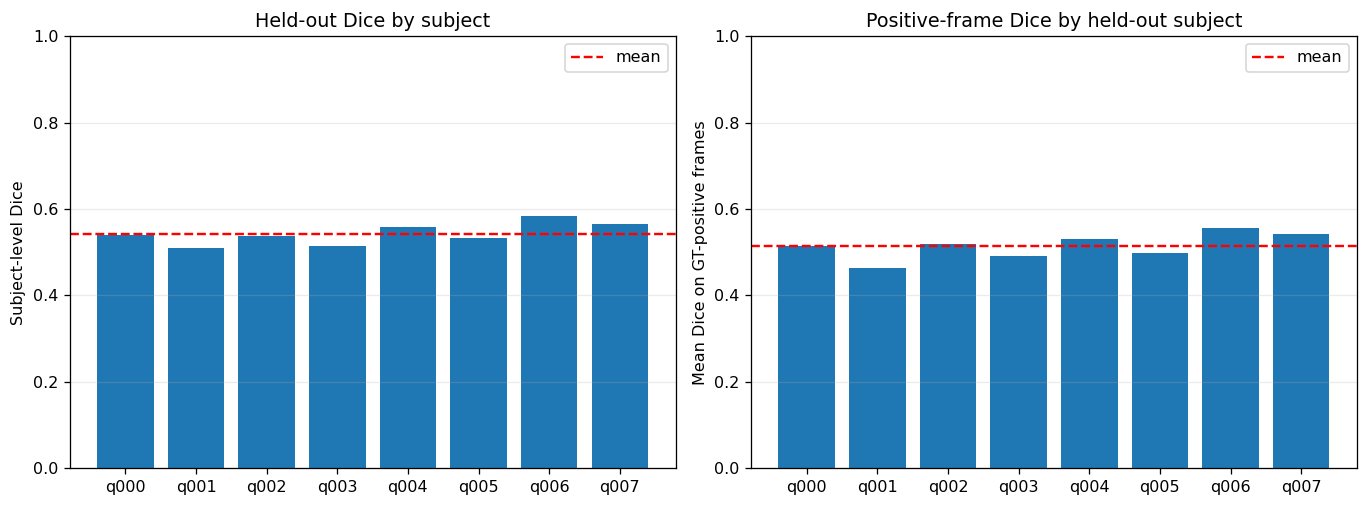

In [10]:
metrics = [
    "subject_micro_dice", "subject_micro_iou", "subject_micro_precision",
    "subject_micro_recall", "mean_positive_frame_dice", "mean_hd95_pixels",
    "mean_assd_pixels", "empty_frame_specificity",
]

overall = {"n_subjects": len(subject_results), "n_test_frames": int(subject_results.frames.sum())}
for metric in metrics:
    values = subject_results[metric].dropna()
    overall[f"mean_{metric}"] = float(values.mean())
    overall[f"sd_{metric}"] = float(values.std(ddof=1))
    overall[f"median_{metric}"] = float(values.median())
    overall[f"iqr_{metric}"] = float(values.quantile(0.75) - values.quantile(0.25))

(WORK_ROOT / "overall_summary.json").write_text(json.dumps(overall, indent=2), encoding="utf-8")
display(pd.Series(overall, name="value").to_frame())

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].bar(subject_results.subject, subject_results.subject_micro_dice)
axes[0].axhline(subject_results.subject_micro_dice.mean(), color="red", linestyle="--", label="mean")
axes[0].set_ylim(0, 1)
axes[0].set_ylabel("Subject-level Dice")
axes[0].set_title("Held-out Dice by subject")
axes[0].legend()
axes[0].grid(axis="y", alpha=0.25)

axes[1].bar(subject_results.subject, subject_results.mean_positive_frame_dice)
axes[1].axhline(subject_results.mean_positive_frame_dice.mean(), color="red", linestyle="--", label="mean")
axes[1].set_ylim(0, 1)
axes[1].set_ylabel("Mean Dice on GT-positive frames")
axes[1].set_title("Positive-frame Dice by held-out subject")
axes[1].legend()
axes[1].grid(axis="y", alpha=0.25)
plt.tight_layout()
fig.savefig(WORK_ROOT / "subject_level_results.png", dpi=180, bbox_inches="tight")
plt.show()


## 10. Package every result

The archive contains fold weights, histories, probabilities, binary predictions, per-frame metrics, subject summaries, overlays, the fold manifest, and the final aggregate report.


In [11]:
archive = shutil.make_archive(str(WORK_ROOT), "zip", root_dir=WORK_ROOT)
print("Created:", archive)
print("Primary result table:", WORK_ROOT / "loso_subject_results.csv")
print("Primary summary:", WORK_ROOT / "overall_summary.json")


Created: /kaggle/working/ungi_unet_8fold_fp32.zip
Primary result table: /kaggle/working/ungi_unet_8fold_fp32/loso_subject_results.csv
Primary summary: /kaggle/working/ungi_unet_8fold_fp32/overall_summary.json


## Reporting rules

- Call this **subject-wise eight-fold cross-validation** or **eight-fold leave-one-subject-out evaluation**.
- Report both subject-level Dice over all frames and positive-frame Dice conditional on a nonempty ground-truth mask, giving their mean ± SD across the eight subjects. Explain that positive-frame Dice excludes false positives on empty frames.
- Keep threshold `0.5` fixed; do not choose a threshold using the test subject.
- Report empty-frame false positives separately from positive-frame segmentation quality.
- State clearly that there are 3,290 frames but only eight independent subjects.
- Treat this as the independent UNGI baseline. Do not merge with another dataset until label meaning, imaging plane, geometry, and subject identity have been checked across datasets.
